In [1]:
import datetime
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.gridspec import GridSpec 
import matplotlib.ticker as mtick

In [2]:
begining = 2025
end = 2031

salario_mensual = 1000
salario_extra = 1500
ahorros = 5000

gastos_mensuales = pd.DataFrame([ 
    ["Coche (mensual)", 120, datetime.datetime(2025,1,1), datetime.datetime(2029,12,1)],
    ["Gimnasio", 40, datetime.datetime(begining,1,1), datetime.datetime(end,12,1)],
], columns=['Concepto', 'Cantidad', 'Fecha_inicio', 'Fecha_final'])

total_gastos_mensuales = gastos_mensuales["Cantidad"].sum(axis=0)

gastos_puntuales = pd.DataFrame([
    ["Coche (pago final)", datetime.datetime(2029,12,1), 7000],
    ["Viaje EEUU", datetime.datetime(2026,4,15), 1000]
], columns=['Concepto', 'Fecha', 'Cantidad'])

In [3]:
## Inicializo

fechas = np.arange(np.datetime64(str(begining) + "-01-01"), np.datetime64(str(end) + "-01-01"), np.timedelta64(1, 'M'), dtype='datetime64[M]').astype('datetime64[D]')

d = {"Fecha": fechas, "Ahorro GASTO": np.zeros((fechas.size)), "Ahorro NO_GASTO" : np.zeros((fechas.size)), "Balance" : np.zeros((fechas.size))}
savings = pd.DataFrame(data=d)

In [4]:
def calculateIngress(datetime64):
    # Calculo ingreso del mes (SIN GASTOS)
    if((datetime64.month == 6) or (datetime64.month == 12)):
        ingreso = salario_mensual + salario_extra
    else:
        ingreso = salario_mensual
    return ingreso

def calculatePayments(datetime64):
    #initialize
    payments = 0
    # iterating to check regular payments
    for index, row2 in gastos_mensuales.iterrows():
        if ((datetime64 >= pd.to_datetime(row2["Fecha_inicio"])) & (datetime64 <= pd.to_datetime(row2['Fecha_final']))):
            payments += gastos_mensuales.loc[index, 'Cantidad']

    # iterating to check regular payments
    for index, row2 in gastos_puntuales.iterrows():
        if ((datetime64.year == pd.to_datetime(row2['Fecha']).year) & (datetime64.month == pd.to_datetime(row2['Fecha']).month)):
            payments += row2['Cantidad']
    
    return payments

# Initialize data
savings.loc[0, "Ahorro GASTO"] = ahorros
savings.loc[0, "Ahorro NO_GASTO"] = ahorros

# Iterate the data
for index, row in savings.iterrows():
    if index != 0:
        ingreso_del_mes = calculateIngress(pd.to_datetime(savings.loc[index, "Fecha"]))
        gastos_del_mes = calculatePayments(pd.to_datetime(savings.loc[index, "Fecha"]))
        savings.loc[index, "Ahorro GASTO"] = savings.loc[index -1, "Ahorro GASTO"] + ingreso_del_mes - gastos_del_mes
        savings.loc[index, "Ahorro NO_GASTO"] = savings.loc[index -1, "Ahorro NO_GASTO"] + ingreso_del_mes
        savings.loc[index, 'Balance'] = ingreso_del_mes - gastos_del_mes

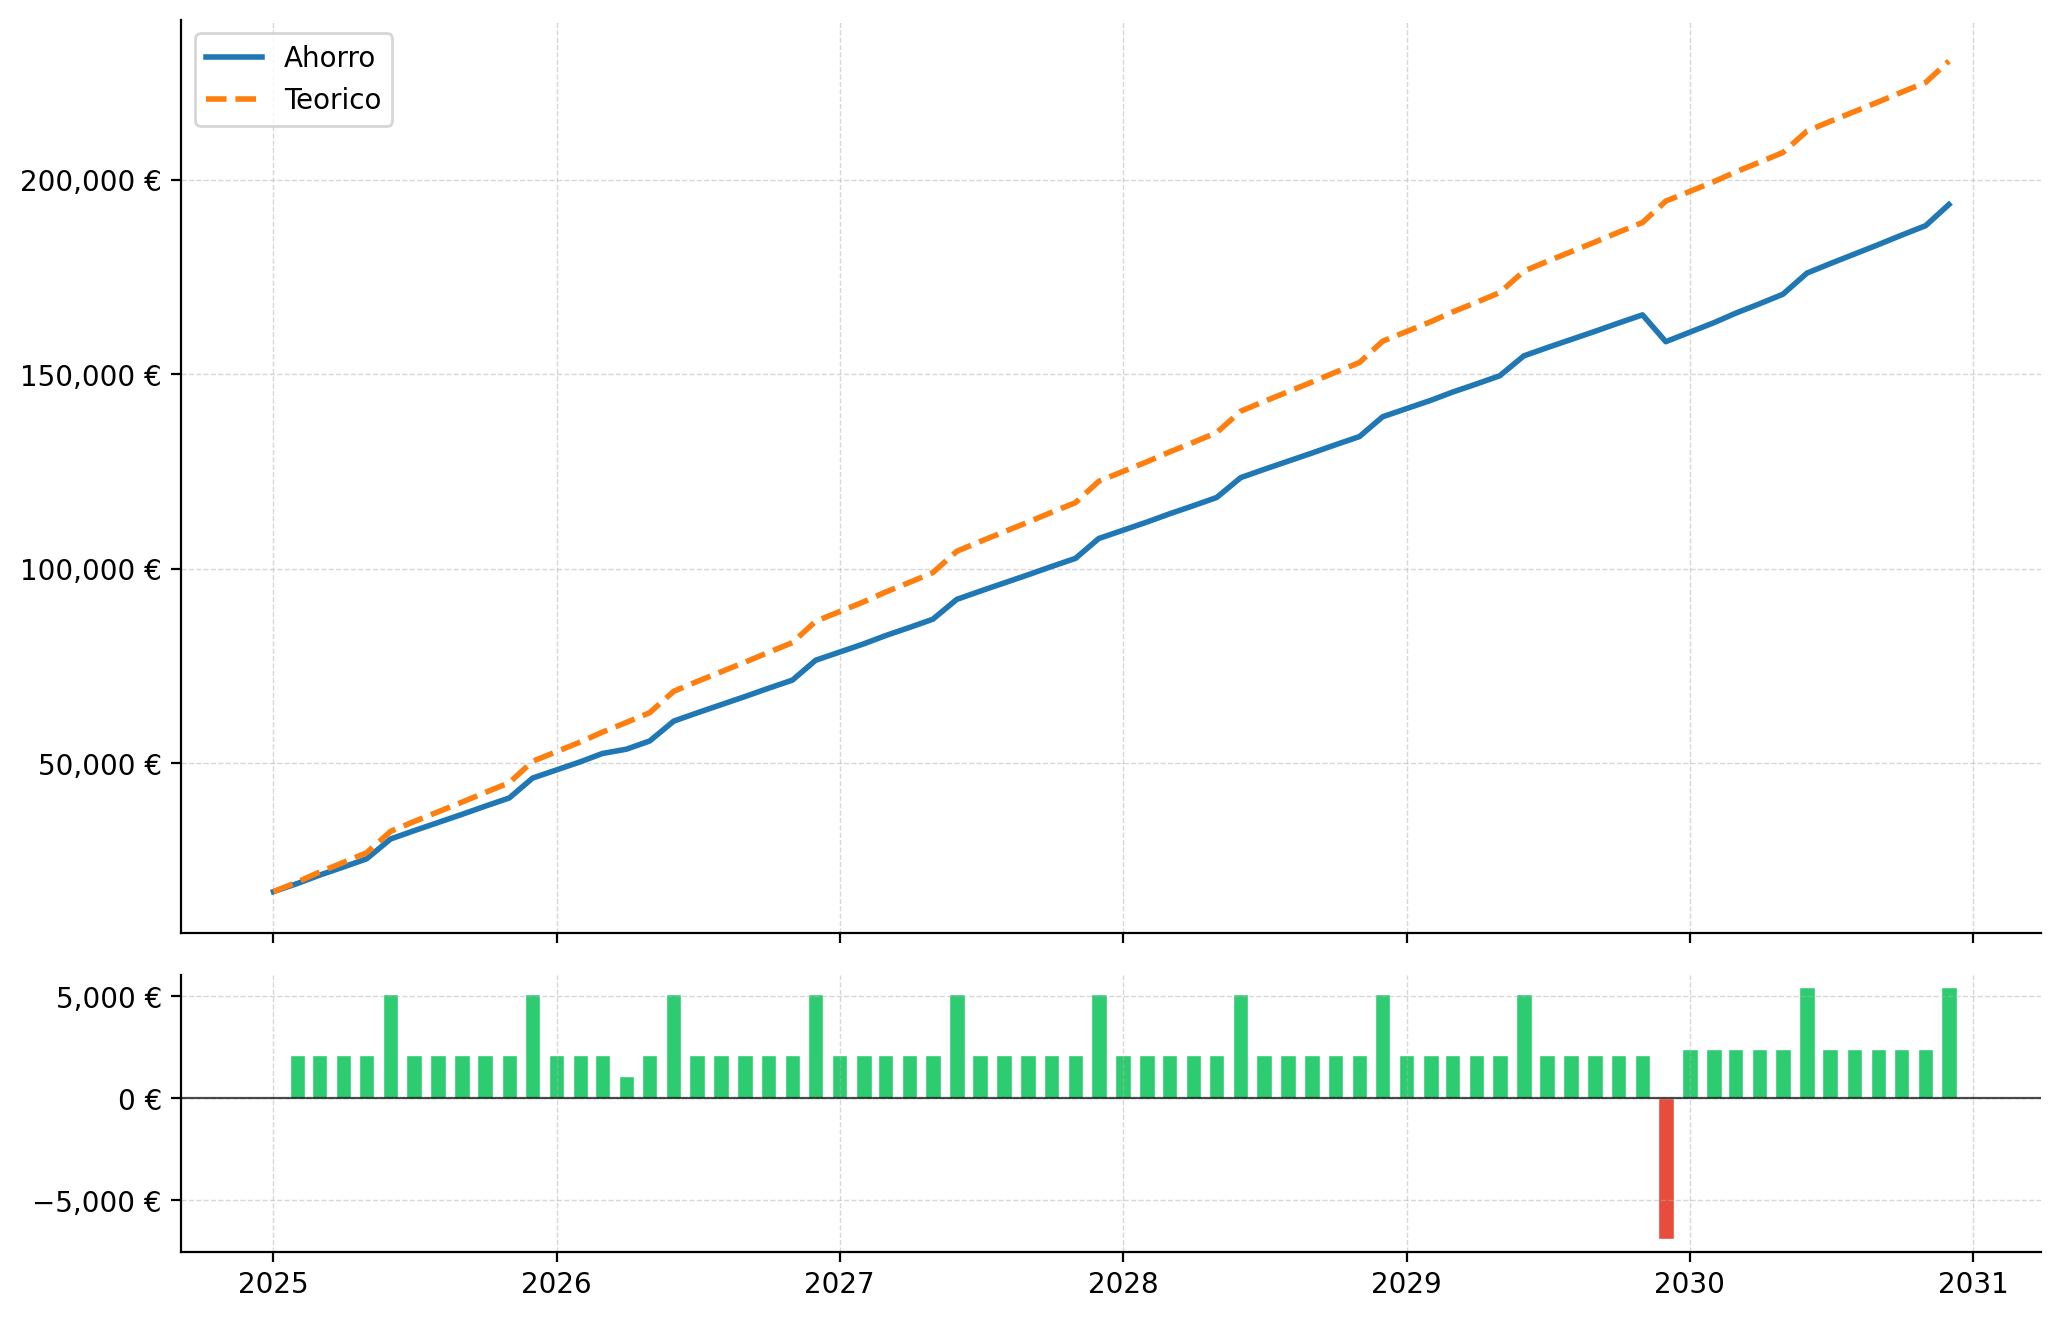

In [5]:
# Config
fig = plt.figure(figsize=(12, 8), dpi=200)
grid = plt.GridSpec(4, 4, hspace=0.15) # Reduced hspace for a tighter look
main_ax = fig.add_subplot(grid[:-1, :])
x_hist = fig.add_subplot(grid[-1, :], sharex=main_ax)

# --- Style Main Plot ---
main_ax.grid(axis='both', linestyle="--", linewidth=0.5, alpha=0.5)
main_ax.tick_params(axis='x', labelbottom=False)

# Currency Formatting
fmt = '{x:,.0f} €' # Using .0f for cleaner labels if cents aren't vital
tick = mtick.StrMethodFormatter(fmt)
main_ax.yaxis.set_major_formatter(tick)

main_ax.plot(savings['Fecha'], savings['Ahorro GASTO'], label='Ahorro', linewidth=2)
main_ax.plot(savings['Fecha'], savings['Ahorro NO_GASTO'], label='Teorico', linestyle = '--', linewidth=2)
main_ax.legend(loc='upper left', frameon=True)

# --- Style Balance Plot (Bottom) ---
# Logic for color-coding: Green for positive, Red for negative
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in savings['Balance']]

x_hist.bar(savings['Fecha'], savings['Balance'], color=colors, edgecolor='white', linewidth=0.5, width=20)

# Add a horizontal baseline at 0 for clarity
x_hist.axhline(0, color='black', linewidth=0.8, alpha=0.7)

# Format the bottom Y-axis as currency too
x_hist.yaxis.set_major_formatter(tick)

# Add vertical grids to match the top plot
x_hist.grid(linestyle="--", linewidth=0.5, alpha=0.5)

# Clean up spines
for ax in [main_ax, x_hist]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Finally
fig.savefig("savings.png", bbox_inches='tight')
plt.show()